# Transformación de datos
Echemos otro vistazo al conjunto de datos de ventas de videojuegos, usando dropna() para excluir los valores ausentes una vez más:

In [5]:
import pandas as pd
df = pd.read_csv('../Datasets/videogames_sales.csv')

df.dropna(inplace=True)

Digamos que necesitamos la puntuación promedio de la crítica para cada género:

In [ ]:
import pandas as pd
df = pd.read_csv('../Datasets/videogames_sales.csv')

df.dropna(inplace=True)

mean_scores = df.groupby('genre')['critic_score'].mean()
print(mean_scores)

genre
Action          95.000000
Fighting        93.000000
Misc            68.250000
Platform        89.666667
Puzzle          77.000000
Racing          90.000000
Role-Playing    90.600000
Shooter         86.384615
Simulation      86.666667
Sports          79.600000
Name: critic_score, dtype: float64


El índice del objeto Series `mean_scores` es la “clave `groupby()`”, en este caso, los valores unívocos de la columna `genre`. Hacer una operación `groupby()` cambia el índice de fila de los datos a las claves por las que estamos agrupando.

Para agrupar por varias columnas, pasamos una lista al método `groupby()`:

In [7]:
import pandas as pd
df = pd.read_csv('../Datasets/videogames_sales.csv')

df.dropna(inplace=True)

grp = df.groupby(['platform', 'genre'])
print(grp['critic_score'].mean())

platform  genre       
3DS       Platform        84.000000
          Simulation      88.000000
DS        Misc            74.500000
          Platform        89.000000
          Puzzle          77.000000
          Racing          91.000000
          Role-Playing    83.000000
          Simulation      86.000000
PC        Simulation      86.000000
PS        Racing          94.500000
          Role-Playing    91.000000
PS2       Action          95.666667
          Racing          92.000000
          Role-Playing    92.000000
PS3       Action          94.333333
          Racing          84.000000
          Shooter         84.000000
PS4       Action          97.000000
          Shooter         83.000000
          Sports          82.000000
PSP       Action          88.000000
Wii       Fighting        93.000000
          Misc            67.200000
          Platform        93.666667
          Racing          82.000000
          Sports          79.000000
X360      Action          97.500000
     

Ahora tenemos la puntuación promedio de la crítica para cada género en cada plataforma. Como agrupamos por dos columnas, nuestro resultado es un objeto Series de múltiples índices con dos valores de índice para cada puntuación promedio, en este caso, `platform` y `genre`.

Aquí la variable `grp` es un objeto que contiene el DataFrame agrupado antes de que procesemos cada grupo con el método `mean()`. Se denomina objeto "en espera". Si intentamos imprimir el objeto `grp`, se mostrará una representación del objeto en forma de texto.

In [8]:
import pandas as pd
df = pd.read_csv('../Datasets/videogames_sales.csv')

df.dropna(inplace=True)

grp = df.groupby(['platform', 'genre'])
print(grp)

Cuando imprimimos `df.groupby('column_name')`, no vemos la impresión de una tabla como ocurriría si imprimiéramos df. En cambio, vemos el tipo de datos del objeto agrupado (`DataFrameGroupBy`) y una cadena (`0x0000022EA82A75B0`) que representa la ubicación en la memoria de la computadora donde se almacena el objeto. No se mostrará ningún resultado hasta que procesemos los grupos.

## Dividir - Aplicar - Combinar
El objeto `DataFrameGroubBy` forma parte de un framework de procesamiento de datos llamado **dividir-aplicar-combinar**:

1. Dividir los datos en grupos
2. Aplicar una función de agregación estadística a cada grupo
3. Combinar los resultados para cada grupo.
En el código a continuación, podemos ilustrar cada uno de los tres componentes de **dividir-aplicar-combinar**:

In [10]:
import pandas as pd
df = pd.read_csv('../Datasets/videogames_sales.csv')
df.dropna(inplace=True)

grp =  df.groupby(['platform', 'genre'])
mean_scores = grp['critic_score'].mean()
print(mean_scores)

platform  genre       
3DS       Platform        84.000000
          Simulation      88.000000
DS        Misc            74.500000
          Platform        89.000000
          Puzzle          77.000000
          Racing          91.000000
          Role-Playing    83.000000
          Simulation      86.000000
PC        Simulation      86.000000
PS        Racing          94.500000
          Role-Playing    91.000000
PS2       Action          95.666667
          Racing          92.000000
          Role-Playing    92.000000
PS3       Action          94.333333
          Racing          84.000000
          Shooter         84.000000
PS4       Action          97.000000
          Shooter         83.000000
          Sports          82.000000
PSP       Action          88.000000
Wii       Fighting        93.000000
          Misc            67.200000
          Platform        93.666667
          Racing          82.000000
          Sports          79.000000
X360      Action          97.500000
     

Dividimos los datos en grupos con `df.groupby(['platform', 'genre'])`, aplicamos el método `mean()` y combinamos el resultado en un objeto Series `grp['critic_score'].mean()`.

Por supuesto, podemos omitir la creación de los objetos `grp` y `mean_scores` y hacer que pandas realice los tres pasos con una sola línea de código:

In [9]:
import pandas as pd
df = pd.read_csv('../Datasets/videogames_sales.csv')
df.dropna(inplace=True)

print(df.groupby(['platform', 'genre'])['critic_score'].mean())

platform  genre       
3DS       Platform        84.000000
          Simulation      88.000000
DS        Misc            74.500000
          Platform        89.000000
          Puzzle          77.000000
          Racing          91.000000
          Role-Playing    83.000000
          Simulation      86.000000
PC        Simulation      86.000000
PS        Racing          94.500000
          Role-Playing    91.000000
PS2       Action          95.666667
          Racing          92.000000
          Role-Playing    92.000000
PS3       Action          94.333333
          Racing          84.000000
          Shooter         84.000000
PS4       Action          97.000000
          Shooter         83.000000
          Sports          82.000000
PSP       Action          88.000000
Wii       Fighting        93.000000
          Misc            67.200000
          Platform        93.666667
          Racing          82.000000
          Sports          79.000000
X360      Action          97.500000
     

# El método `agg()`
Hasta ahora, solo hemos aplicado una única función a nuestros grupos. Pero, ¿qué pasa si queremos calcular diferentes estadísticas de resumen para diferentes columnas? Por ejemplo, tanto la puntuación promedio de los críticos como el total de ventas en Japón para cada grupo. Podemos conseguirlo utilizando el método `agg()`, que es la abreviatura de "aggregate" (agregar).

El método `agg()` usa un diccionario como entrada donde las claves son los nombres de columnas y los valores correspondientes son las funciones de agregación que quieres aplicarles:

In [11]:
import pandas as pd
df = pd.read_csv('../Datasets/videogames_sales.csv')
df.dropna(inplace=True)

agg_dict = {'critic_score': 'mean', 'jp_sales': 'sum'}

grp = df.groupby(['platform', 'genre'])
print(grp.agg(agg_dict))

                       critic_score  jp_sales
platform genre                               
3DS      Platform         84.000000      4.61
         Simulation       88.000000      4.39
DS       Misc             74.500000      6.14
         Platform         89.000000      6.50
         Puzzle           77.000000      5.32
         Racing           91.000000      4.13
         Role-Playing     83.000000      2.69
         Simulation       86.000000      5.33
PC       Simulation       86.000000      0.00
PS       Racing           94.500000      4.23
         Role-Playing     91.000000      6.91
PS2      Action           95.666667      1.18
         Racing           92.000000      2.97
         Role-Playing     92.000000      2.73
PS3      Action           94.333333      1.55
         Racing           84.000000      0.81
         Shooter          84.000000      1.89
PS4      Action           97.000000      0.38
         Shooter          83.000000      0.14
         Sports           82.00000

¡Incluso puedes aplicar tus propias funciones personalizadas con `agg()` de esta manera! Echa un vistazo:

In [13]:
import pandas as pd
df = pd.read_csv('../Datasets/videogames_sales.csv')
df.dropna(inplace=True)

def double_it(sales):
    sales = sales.sum() * 2
    return sales

agg_dict = {'jp_sales': double_it}
grp = df.groupby(['platform', 'genre'])
print(grp.agg(agg_dict))

                       jp_sales
platform genre                 
3DS      Platform          9.22
         Simulation        8.78
DS       Misc             12.28
         Platform         13.00
         Puzzle           10.64
         Racing            8.26
         Role-Playing      5.38
         Simulation       10.66
PC       Simulation        0.00
PS       Racing            8.46
         Role-Playing     13.82
PS2      Action            2.36
         Racing            5.94
         Role-Playing      5.46
PS3      Action            3.10
         Racing            1.62
         Shooter           3.78
PS4      Action            0.76
         Shooter           0.28
         Sports            0.12
PSP      Action            0.48
Wii      Fighting          5.32
         Misc             14.02
         Platform         13.76
         Racing            7.58
         Sports           26.36
X360     Action            0.40
         Misc              0.48
         Role-Playing      0.20
        

## Resumen
Vamos a recordar todo lo que hemos estudiado en esta lección:

* Método `groupby()`: método utilizado para agrupar datos por una o varias columnas en un DataFrame.
* `grp = df.groupby(['platform', 'genre'])` agrupará por dos columnas al mismo tiempo.
* Método `agg()`: método utilizado para calcular estadísticas agregadas para cada grupo en un DataFrame agrupado. Pásale un diccionario con ítems de `'column':'function'`.
* Framework `dividir-aplicar-combinar`: framework de tratamiento de datos que describe el proceso de dividir un conjunto de datos en grupos, aplicar una función a cada grupo y, a continuación, combinar los resultados en una única estructura de datos.
* Método `mean()`: método utilizado para calcular la media de un conjunto de valores.
* Método `sum()`: método utilizado para calcular la suma de un conjunto de valores.
* Método `dropna()`: método utilizado para eliminar valores ausentes (NaN) de un DataFrame.
* Objeto `DataFrameGroupBy`: objeto que contiene el DataFrame agrupado antes de que este sea procesado con una función de agregación.

Ahora vas a hacer lo siguiente:

* Crear un diccionario para calcular los resultados por cada género:
  * Suma del total de ventas.
  * Ventas promedio NA (Norteamérica).
  * Ventas promedio EU (Europa).
  * Ventas promedio JP (Japón).
* Asignar el diccionario a una variable llamada `agg_dict` con las tuplas descritas anteriormente.
* Asignar el resultado de `agg()` a una variable llamada genre.
* Imprimir `genre`.

In [15]:
import pandas as pd
df = pd.read_csv('../Datasets/videogames_sales.csv')
df.dropna(inplace=True)

df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales']

grp = df.groupby('genre')

agg_dict = {'total_sales': 'sum', 'na_sales': 'mean', 'eu_sales': 'mean', 'jp_sales': 'mean'}

genre = grp.agg(agg_dict)

print(genre)

              total_sales   na_sales   eu_sales  jp_sales
genre                                                    
Action             110.02   6.095000   4.552000  0.355000
Fighting            11.83   6.620000   2.550000  2.660000
Misc               105.52   6.917500   4.598750  1.673750
Platform            89.80   7.315000   4.653333  2.998333
Puzzle              14.10   3.430000   5.350000  5.320000
Racing              99.48   6.587143   5.348571  2.275714
Role-Playing        39.21   3.202000   2.154000  2.486000
Shooter            128.19   6.347692   3.310769  0.202308
Simulation          27.47   1.840000   4.076667  3.240000
Sports             151.79  15.204000  12.506000  2.648000


# Tablas dinámicas
Las tablas dinámicas son una gran herramienta para sintetizar conjuntos de datos y explorar sus diferentes dimensiones. Son muy populares en las aplicaciones de hojas de cálculo como Excel, pero es aún más impresionante crearlas mediante programación con pandas.

Supongamos que queremos determinar el total de ventas en Europa de cada género en cada plataforma. Las tablas dinámicas ofrecen un método rápido y cómodo para conseguirlo. Primero, vamos a examinar el código y luego a comentarlo. Para simplificar las cosas, eliminaremos las filas con valores ausentes.

In [16]:
import pandas as pd
df = pd.read_csv('../Datasets/videogames_sales.csv')
df.dropna(inplace=True)

pivot_data = df.pivot_table(index='genre',
                            columns='platform',
                            values='eu_sales',
                            aggfunc='sum'
                            )

print(pivot_data)

platform       3DS     DS    PC    PS    PS2    PS3   PS4   PSP    Wii   X360  \
genre                                                                           
Action         NaN    NaN   NaN   NaN  10.40  17.79  6.31  2.81    NaN   8.21   
Fighting       NaN    NaN   NaN   NaN    NaN    NaN   NaN   NaN   2.55    NaN   
Misc           NaN  11.05   NaN   NaN    NaN    NaN   NaN   NaN  20.85   4.89   
Platform      6.14   9.14   NaN   NaN    NaN    NaN   NaN   NaN  12.64    NaN   
Puzzle         NaN   5.35   NaN   NaN    NaN    NaN   NaN   NaN    NaN    NaN   
Racing         NaN   7.47   NaN  7.29   5.10   4.82   NaN   NaN  12.76    NaN   
Role-Playing   NaN   1.72   NaN  4.19   2.07    NaN   NaN   NaN    NaN   2.79   
Shooter        NaN    NaN   NaN   NaN    NaN  17.37  3.48   NaN    NaN  20.66   
Simulation    2.36   3.45  6.42   NaN    NaN    NaN   NaN   NaN    NaN    NaN   
Sports         NaN    NaN   NaN   NaN    NaN    NaN  6.12   NaN  56.41    NaN   

platform        XB  
genre 

Creamos una tabla dinámica utilizando el método `pivot_table()`, que tiene un nombre muy apropiado. Los parámetros que utilizamos fueron:

* `index=`: la columna cuyos valores se convierten en índices en la tabla dinámica;
* `columns=`: la columna cuyos valores se convierten en columnas en la tabla dinámica;
* `values=`: la columna cuyos valores queremos agregar en la tabla dinámica;
* `gfunc=`: la función de agregación que queremos aplicar a los valores en cada grupo de filas y columnas.

Cada celda de la tabla dinámica de arriba contiene las ventas totales en Europa para cada combinación particular de género/plataforma. También imprimimos el tipo de datos de la tabla dinámica para mostrar que es un DataFrame de pandas, que ya conocemos muy bien.

El uso de una tabla dinámica aquí es conveniente porque nos permite fácilmente excluir todas las columnas de df que no nos interesan para nuestro análisis. Además, puede ser más fácil de leer que el resultado equivalente de `groupby()`, como puedes ver a continuación.

In [17]:
import pandas as pd
df = pd.read_csv('../Datasets/videogames_sales.csv')
df.dropna(inplace=True)

groupby_data = df.groupby(['genre', 'platform'])['eu_sales'].sum()
print(groupby_data)

genre         platform
Action        PS2         10.40
              PS3         17.79
              PS4          6.31
              PSP          2.81
              X360         8.21
Fighting      Wii          2.55
Misc          DS          11.05
              Wii         20.85
              X360         4.89
Platform      3DS          6.14
              DS           9.14
              Wii         12.64
Puzzle        DS           5.35
Racing        DS           7.47
              PS           7.29
              PS2          5.10
              PS3          4.82
              Wii         12.76
Role-Playing  DS           1.72
              PS           4.19
              PS2          2.07
              X360         2.79
Shooter       PS3         17.37
              PS4          3.48
              X360        20.66
              XB           1.53
Simulation    3DS          2.36
              DS           3.45
              PC           6.42
Sports        PS4          6.12
              Wii

Hemos filtrado el conjunto de datos de videojuegos para que solo contenga juegos que se lanzaron en el 2000 o después. Crea una tabla dinámica a partir del conjunto de datos filtrados que contenga el valor promedio para las ventas en Japón para cada combinación de género y año de lanzamiento.

* Los géneros servirán de índice.
* Las columnas de la tabla dinámica serán los años de lanzamiento.
* Utiliza la columna correspondiente como valores a ser agregados.
* Utiliza la función de agregación apropiada.
* Asigna el resultado a una variable llamada `df_pivot` y luego muéstralo.

In [19]:
import pandas as pd
df = pd.read_csv('../Datasets/videogames_sales.csv')
df.dropna(inplace=True)
df = df[df['year_of_release'] >= 2000]


df_pivot = df.pivot_table(index='genre',
                            columns='year_of_release',
                            values='jp_sales',
                            aggfunc='mean'
                            )

print(df_pivot)

year_of_release  2001.0  2002.0  2004.0  2005.0  2006.0  2007.0  2008.0  \
genre                                                                     
Action             0.30    0.47    0.41    0.24     NaN     NaN    0.29   
Fighting            NaN     NaN     NaN     NaN     NaN     NaN    2.66   
Misc                NaN     NaN     NaN    4.16    2.93    1.78     NaN   
Platform            NaN     NaN     NaN     NaN    6.50    1.20     NaN   
Puzzle              NaN     NaN     NaN    5.32     NaN     NaN     NaN   
Racing             1.87     NaN    1.10    4.13     NaN     NaN    3.79   
Role-Playing       2.73     NaN     NaN     NaN     NaN     NaN    2.69   
Shooter             NaN     NaN    0.05     NaN     NaN    0.13     NaN   
Simulation          NaN     NaN     NaN    5.33     NaN     NaN     NaN   
Sports              NaN     NaN     NaN     NaN    3.77    3.60     NaN   

year_of_release  2009.0    2010.0  2011.0    2012.0  2013.0  2014.0  2015.0  
genre                

# Combinar DataFrames con `concat()`
Queremos conocer algunas estadísticas generales de las distribuidoras de juegos, en particular:

* Su puntuación promedio de la crítica
* Sus ventas totales
  
Como ya hemos visto, podemos hacerlo usando `groupby()`. Primero, obtengamos la puntuación de reseña promedio para cada distribuidora:

In [20]:
import pandas as pd
df = pd.read_csv('../Datasets/videogames_sales.csv')
df.dropna(inplace=True)

mean_scores = df.groupby('publisher')['critic_score'].mean()
print(mean_scores)


publisher
Activision                     85.000000
Bethesda Softworks             96.000000
Electronic Arts                85.333333
Microsoft Game Studios         83.500000
Nintendo                       81.409091
Sony Computer Entertainment    91.571429
SquareSoft                     90.000000
Take-Two Interactive           95.777778
Ubisoft                        74.000000
Name: critic_score, dtype: float64


Obtengamos también el número de ventas. La forma más sencilla de hacerlo es con un segundo `groupby()`:

In [22]:
import pandas as pd
df = pd.read_csv('../Datasets/videogames_sales.csv')
df.dropna(inplace=True)

df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales']
num_sales = df.groupby('publisher')['total_sales'].sum()

print(num_sales)

publisher
Activision                     101.75
Bethesda Softworks               7.94
Electronic Arts                 20.91
Microsoft Game Studios          46.57
Nintendo                       408.66
Sony Computer Entertainment     62.41
SquareSoft                       7.63
Take-Two Interactive           103.82
Ubisoft                         17.72
Name: total_sales, dtype: float64


Observa que el índice de ambos resultados es la columna `publisher` porque agrupamos por `publisher` en ambos casos. Como ambos resultados comparten el mismo índice, podemos unir fácilmente los resultados en un DataFrame usando la función `concat()` de pandas:

In [28]:
import pandas as pd
df = pd.read_csv('../Datasets/videogames_sales.csv')
df.dropna(inplace=True)

# Puntuación promedio de la crítica por distribuidor
mean_scores = df.groupby('publisher')['critic_score'].mean()

# Ventas totales por distribuidor
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales']
num_sales = df.groupby('publisher')['total_sales'].sum()

df_concat = pd.concat([mean_scores, num_sales], axis='columns')

print(df_concat)

                             critic_score  total_sales
publisher                                             
Activision                      85.000000       101.75
Bethesda Softworks              96.000000         7.94
Electronic Arts                 85.333333        20.91
Microsoft Game Studios          83.500000        46.57
Nintendo                        81.409091       408.66
Sony Computer Entertainment     91.571429        62.41
SquareSoft                      90.000000         7.63
Take-Two Interactive            95.777778       103.82
Ubisoft                         74.000000        17.72


En general, `concat()` espera una lista de objetos de tipo Series y/o DataFrame. Para obtener nuestro resultado, pasamos una lista de variables de Series a `concat()` y configuramos `axis='columns'` para asegurarnos de que se combinaran como columnas.

Ten en cuenta que los nombres de las columnas originales se conservan en el DataFrame concatenado.

Podemos renombrar columnas utilizando el método `columns`. Se puede llamar en un DataFrame y pasarle una lista de nuevos nombres de columnas para reemplazar las existentes. Los nuevos nombres deben pasarse en el mismo orden que los nombres originales de las columnas.

Cambiemos el nombre de `critic_score`, ya que ahora representa un promedio:

In [30]:
import pandas as pd
df = pd.read_csv('../Datasets/videogames_sales.csv')
df.dropna(inplace=True)

# Puntuación promedio de la crítica por distribuidor
mean_scores = df.groupby('publisher')['critic_score'].mean()

# Ventas totales por distribuidor
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales']
num_sales = df.groupby('publisher')['total_sales'].sum()

df_concat = pd.concat([mean_scores, num_sales], axis='columns')
df_concat.columns = ['avg_critic_score', 'total_score']

print(df_concat)

                             avg_critic_score  total_score
publisher                                                 
Activision                          85.000000       101.75
Bethesda Softworks                  96.000000         7.94
Electronic Arts                     85.333333        20.91
Microsoft Game Studios              83.500000        46.57
Nintendo                            81.409091       408.66
Sony Computer Entertainment         91.571429        62.41
SquareSoft                          90.000000         7.63
Take-Two Interactive                95.777778       103.82
Ubisoft                             74.000000        17.72


En general, es una buena idea cambiar el nombre de las columnas después de agruparlas y procesarlas para que sean más indicativas de cómo se procesaron las columnas.

Es posible que hayas notado que podríamos obtener el mismo resultado que antes usando `agg()`. Sin embargo, `concat()` es bastante versátil. Podemos utilizarlo para concatenar DataFrames:

* por filas, suponiendo que tengan el mismo número de columnas;
* por columnas si tienen el mismo número de filas.

Para concatenar filas de DataFrames separados, podemos usar `concat()` y configurar `axis='index'` (u omitir este parámetro, ya que axis='index' es el argumento predeterminado). Alternativamente, podemos utilizar números enteros para el argumento `index=`, donde `index=0` concatenará filas y `index=1` concatenará columnas.

Aquí hay un ejemplo en el que filtramos los datos en dos DataFrames separados según el género y luego los recombinamos en un solo DataFrame:

In [ ]:
import pandas as pd
df = pd.read_csv('../Datasets/videogames_sales.csv')
df.dropna(inplace=True)

rpgs = df[df['genre'] == 'Role-Playing']
platformers = df[df['genre'] == 'Platform']

df_concat = pd.concat([rpgs, platformers])
print(df_concat[['name', 'genre']])

                           name platform  year_of_release         genre  \
65            Final Fantasy VII       PS           1997.0  Role-Playing   
75  The Elder Scrolls V: Skyrim     X360           2011.0  Role-Playing   
84              Final Fantasy X      PS2           2001.0  Role-Playing   
88           Final Fantasy VIII       PS           1999.0  Role-Playing   
90     Pokémon Platinum Version       DS           2008.0  Role-Playing   
6         New Super Mario Bros.       DS           2006.0      Platform   
8     New Super Mario Bros. Wii      Wii           2009.0      Platform   
49           Super Mario Galaxy      Wii           2007.0      Platform   
53          Super Mario 3D Land      3DS           2011.0      Platform   
62      New Super Mario Bros. 2      3DS           2012.0      Platform   
97         Super Mario Galaxy 2      Wii           2010.0      Platform   

                      publisher              developer  na_sales  eu_sales  \
65  Sony Computer Ent

Leímos los datos, creamos una columna `total_sales` y calculamos las ventas totales para cada plataforma en la variable total_sales.

Tienes que calcular el número total de distribuidoras que crearon un juego en cada plataforma, utilizando `nunique()`. Asigna el resultado a una variable llamada `num_pubs` y luego muéstralo.

In [ ]:
import pandas as pd
df = pd.read_csv('../Datasets/videogames_sales.csv')
df.dropna(inplace=True)

df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales']

total_sales = df.groupby('platform')['total_sales'].sum()

num_pubs = df.groupby('platform')['publisher'].nunique()

print(num_pubs)

platform
3DS     1
DS      1
PC      1
PS      2
PS2     2
PS3     4
PS4     3
PSP     1
Wii     2
X360    4
XB      1
Name: publisher, dtype: int64


Combina `total_sales` y `num_pubs` por columnas en un DataFrame llamado platforms usando `concat()`. Cambia los nombres de las columnas en platforms a `total_sales` y `num_publishers`, respectivamente, luego imprime platforms.

In [35]:
import pandas as pd
df = pd.read_csv('../Datasets/videogames_sales.csv')
df.dropna(inplace=True)

df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales']

total_sales = df.groupby('platform')['total_sales'].sum()

num_pubs = df.groupby('platform')['publisher'].nunique()

platforms = pd.concat([total_sales, num_pubs], axis='columns')

platforms.columns = ['total_sales', 'num_publishers']

print(platforms)

          total_sales  num_publishers
platform                             
3DS             28.08               1
DS             107.11               1
PC               7.41               1
PS              35.81               2
PS2             62.05               2
PS3             80.10               4
PS4             24.38               3
PSP              5.95               1
Wii            291.19               2
X360           126.93               4
XB               8.40               1


# Combinar DataFrames con `merge()`
La concatenación de DataFrames conserva la cantidad total de datos. Por ejemplo, combinar un DataFrame que tiene dos columnas y tres filas con otro DataFrame que tiene las mismas dos columnas y cinco filas da como resultado un DataFrame con dos columnas y ocho filas. El número total de celdas antes y después de la concatenación es dieciséis.

En esta lección, aprenderás a combinar DataFrames utilizando el método `merge()` de forma que afecte a la cantidad de datos con los que estás trabajando.

Considera el siguiente ejemplo: dos estudiantes de literatura acuerdan que uno escribirá la mitad de la lista de lectura de verano de la pizarra mientras el otro mira YouTube. Después el primero irá a la cafetería, mientras que el segundo copia el resto de la lista. Finalmente, los dos combinarán las listas. ¡Trabajo en equipo! Vamos a ver cómo les fue:

In [36]:
import pandas as pd

first_pupil_df = pd.DataFrame(
    {
        'author': ['Alcott', 'Fitzgerald', 'Steinbeck', 'Twain', 'Hemingway'],
        'title': ['Little Women',
                  'The Great Gatsby',
                  'Of Mice and Men',
                  'The Adventures of Tom Sawyer',
                  'The Old Man and the Sea'
                 ],
    }
)
second_pupil_df = pd.DataFrame(
    {
        'author': ['Steinbeck', 'Twain', 'Hemingway', 'Salinger', 'Hawthorne'],
        'title': ['East of Eden',
                  'The Adventures of Huckleberry Finn',
                  'For Whom the Bell Tolls',
                  'The Catcher in the Rye',
                  'The Scarlett Letter'
                 ],
    }
)

print(first_pupil_df)
print()
print(second_pupil_df)

       author                         title
0      Alcott                  Little Women
1  Fitzgerald              The Great Gatsby
2   Steinbeck               Of Mice and Men
3       Twain  The Adventures of Tom Sawyer
4   Hemingway       The Old Man and the Sea

      author                               title
0  Steinbeck                        East of Eden
1      Twain  The Adventures of Huckleberry Finn
2  Hemingway             For Whom the Bell Tolls
3   Salinger              The Catcher in the Rye
4  Hawthorne                 The Scarlett Letter


## Unión interna
Usemos el método `merge()` para combinar entradas que tienen los mismos autores. El nombre de la columna en la que se realizará la fusión se pasa al parámetro `on=`, en este caso, `author`:

In [37]:
import pandas as pd

first_pupil_df = pd.DataFrame(
    {
        'author': ['Alcott', 'Fitzgerald', 'Steinbeck', 'Twain', 'Hemingway'],
        'title': ['Little Women',
                  'The Great Gatsby',
                  'Of Mice and Men',
                  'The Adventures of Tom Sawyer',
                  'The Old Man and the Sea'
                 ],
    }
)
second_pupil_df = pd.DataFrame(
    {
        'author': ['Steinbeck', 'Twain', 'Hemingway', 'Salinger', 'Hawthorne'],
        'title': ['East of Eden',
                  'The Adventures of Huckleberry Finn',
                  'For Whom the Bell Tolls',
                  'The Catcher in the Rye',
                  'The Scarlett Letter'
                 ],
    }
)

both_pupils = first_pupil_df.merge(second_pupil_df, on='author')
print(both_pupils)

      author                       title_x                             title_y
0  Steinbeck               Of Mice and Men                        East of Eden
1      Twain  The Adventures of Tom Sawyer  The Adventures of Huckleberry Finn
2  Hemingway       The Old Man and the Sea             For Whom the Bell Tolls


El resultado contiene solo aquellos autores que están presentes en ambos DataFrames originales.

El DataFrame fusionado incluye todas las columnas de los DataFrames originales, pero solo se conservan las filas con autores compartidos. Ya que ambos DataFrames originales tienen una columna llamada `title`, pandas agregó los sufijos`_x` y `_y` para diferenciarlas en el DataFrame fusionado. Cabe destacar que el DataFrame fusionado solo tiene 9 celdas, frente a las 20 celdas de los DataFrame originales: ¡la cantidad de datos ha cambiado!

Este modo de fusionar se denomina unión interna (inner merge). Existen otros tipos de fusiones, que pueden especificarse con el parámetro `how=` de `merge()`. Pero `'inner'` es el argumento por defecto para `how=`, así que no necesitamos incluirlo arriba.

## Unión externa
Una unión externa (outer merge) se diferencia de una unión interna en que todos los valores en la columna especificada se conservan de ambos DataFrames originales, pero el DataFrame fusionado tiene valores ausentes donde no hay ninguna coincidencia. Lo mejor es ilustrar esto con un ejemplo:

In [38]:
import pandas as pd

first_pupil_df = pd.DataFrame(
    {
        'author': ['Alcott', 'Fitzgerald', 'Steinbeck', 'Twain', 'Hemingway'],
        'title': ['Little Women',
                  'The Great Gatsby',
                  'Of Mice and Men',
                  'The Adventures of Tom Sawyer',
                  'The Old Man and the Sea'
                 ],
    }
)
second_pupil_df = pd.DataFrame(
    {
        'author': ['Steinbeck', 'Twain', 'Hemingway', 'Salinger', 'Hawthorne'],
        'title': ['East of Eden',
                  'The Adventures of Huckleberry Finn',
                  'For Whom the Bell Tolls',
                  'The Catcher in the Rye',
                  'The Scarlett Letter'
                 ],
    }
)

both_pupils = first_pupil_df.merge(second_pupil_df, on='author', how='outer')
print(both_pupils)

       author                       title_x  \
0      Alcott                  Little Women   
1  Fitzgerald              The Great Gatsby   
2   Hawthorne                           NaN   
3   Hemingway       The Old Man and the Sea   
4    Salinger                           NaN   
5   Steinbeck               Of Mice and Men   
6       Twain  The Adventures of Tom Sawyer   

                              title_y  
0                                 NaN  
1                                 NaN  
2                 The Scarlett Letter  
3             For Whom the Bell Tolls  
4              The Catcher in the Rye  
5                        East of Eden  
6  The Adventures of Huckleberry Finn  


Hay 7 autores únicos en ambos DataFrames originales, cada uno se representa con una fila en el DataFrame fusionado. Para los autores en el primer DataFrame que no están también en el segundo (es decir, `Alcott` y `Fitzgerald`), hay valores `NaN` en la columna que proviene del segundo DataFrame (es decir, `title_y`), y viceversa. Además, observa que ahora tenemos 21 celdas de datos.

## Unión izquierda
El último tipo de unión que nos gustaría discutir es la unión izquierda (left merge), que podemos realizar pasando `how='left'` a `merge()`. En una unión izquierda, todos los valores del DataFrame izquierdo (en el que llamamos `merge()`) están presentes en el DataFrame fusionado. Los valores del DataFrame derecho (el que pasamos como entrada a `merge()`) solo se conservan para los valores que coinciden con la columna especificada en el DataFrame izquierdo. Una vez más, se explica mejor con un ejemplo:

In [39]:
import pandas as pd

first_pupil_df = pd.DataFrame(
    {
        'author': ['Alcott', 'Fitzgerald', 'Steinbeck', 'Twain', 'Hemingway'],
        'title': ['Little Women',
                  'The Great Gatsby',
                  'Of Mice and Men',
                  'The Adventures of Tom Sawyer',
                  'The Old Man and the Sea'
                 ],
    }
)
second_pupil_df = pd.DataFrame(
    {
        'author': ['Steinbeck', 'Twain', 'Hemingway', 'Salinger', 'Hawthorne'],
        'title': ['East of Eden',
                  'The Adventures of Huckleberry Finn',
                  'For Whom the Bell Tolls',
                  'The Catcher in the Rye',
                  'The Scarlett Letter'
                 ],
    }
)

both_pupils = first_pupil_df.merge(second_pupil_df, on='author', how='left')
print(both_pupils)

       author                       title_x  \
0      Alcott                  Little Women   
1  Fitzgerald              The Great Gatsby   
2   Steinbeck               Of Mice and Men   
3       Twain  The Adventures of Tom Sawyer   
4   Hemingway       The Old Man and the Sea   

                              title_y  
0                                 NaN  
1                                 NaN  
2                        East of Eden  
3  The Adventures of Huckleberry Finn  
4             For Whom the Bell Tolls  


Como puedes ver, todos los autores y títulos del primer estudiante están en el DataFrame fusionado, pero las filas con `Salinger` y `Hawthorne` del segundo estudiante no lo están porque esos autores no aparecen en el DataFrame del primer estudiante.

Esta unión izquierda contiene 15 celdas de datos, que difieren de la cantidad original y las cantidades de cada una de las otras uniones que hicimos.

Ten en cuenta que también existe una unión derecha (right merge, `how='right'`). Sin embargo, funciona de manera idéntica a una unión izquierda, excepto que el DataFrame combinado conserva todos los valores del DataFrame derecho en vez del izquierdo. Se puede lograr el mismo resultado realizando una unión izquierda y cambiando el orden de los DataFrames.

Aquí tienes un diagrama de Venn que ilustra todas las opciones de fusión que hemos comentado, para que sea aún más fácil de entender:

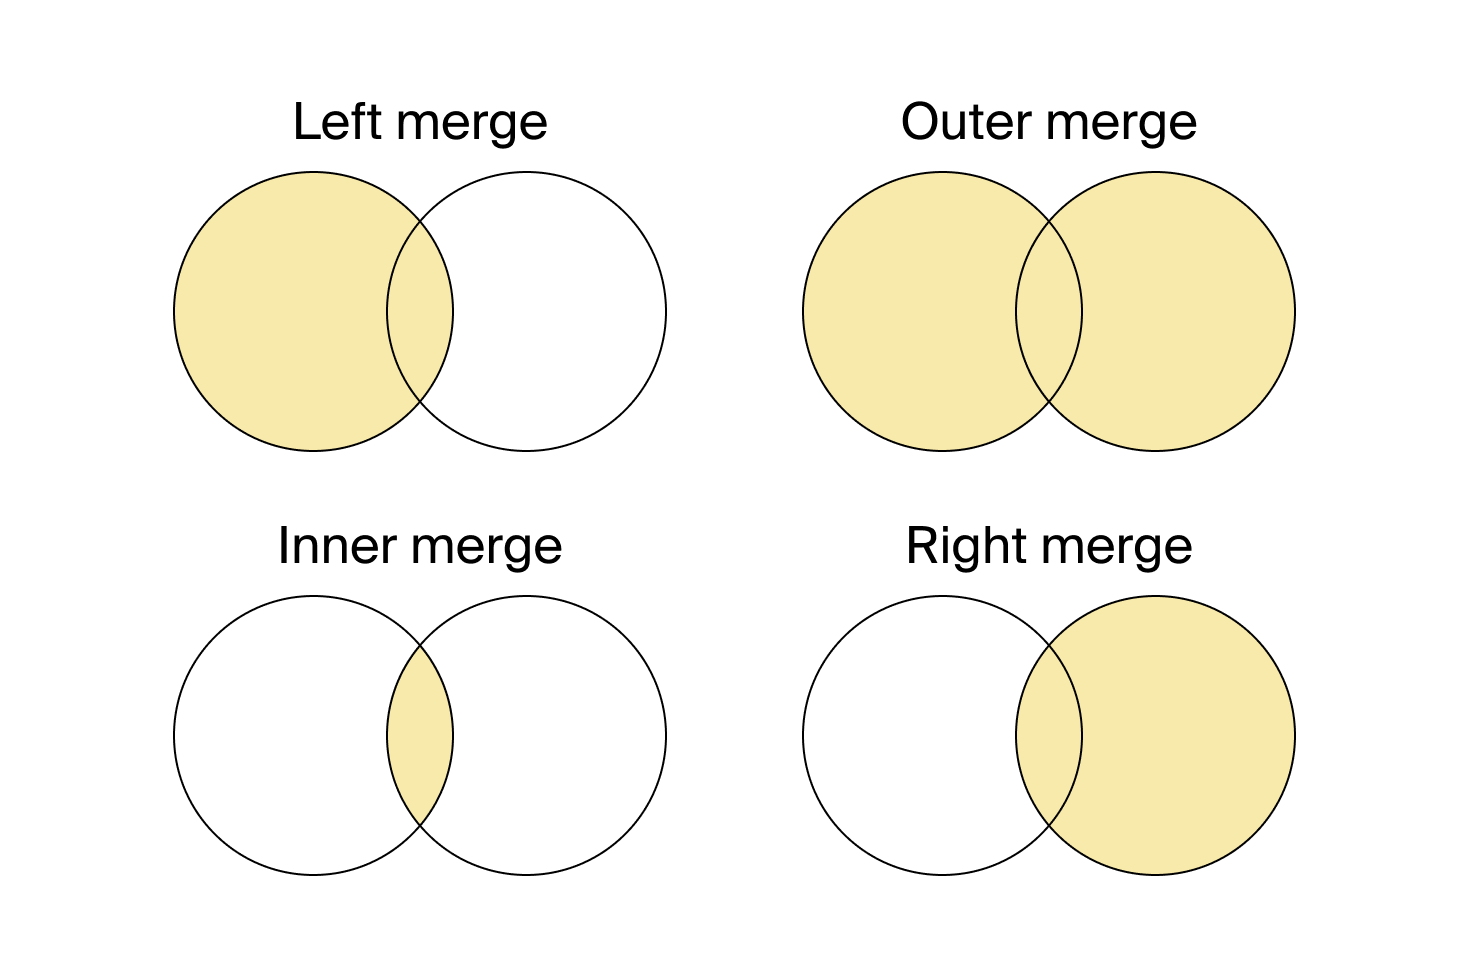

### Tener en cuenta los nombres de las columnas
Hay dos aspectos de todas las uniones realizadas hasta ahora que debemos abordar:

1. El DataFrame fusionado tiene los sufijos `_x` y `_y` agregados a los nombres de las columnas `title`.
2. La columna en la que realizamos la unión tiene el mismo nombre en ambos DataFrames, `author`.

Cuando se fusionan DataFrames en pandas, es importante asegurarse de que no hay dos columnas con el mismo nombre. En caso contrario, pandas añadirá automáticamente los sufijos `_x` y `_y`. Sin embargo, estos sufijos no son muy descriptivos. Para establecer mejores sufijos, pasa una tupla de sufijos al parámetro `suffixes=` en `merge()`:

In [41]:
import pandas as pd

first_pupil_df = pd.DataFrame(
    {
        'author': ['Alcott', 'Fitzgerald', 'Steinbeck', 'Twain', 'Hemingway'],
        'title': ['Little Women',
                  'The Great Gatsby',
                  'Of Mice and Men',
                  'The Adventures of Tom Sawyer',
                  'The Old Man and the Sea'
                 ],
    }
)
second_pupil_df = pd.DataFrame(
    {
        'author': ['Steinbeck', 'Twain', 'Hemingway', 'Salinger', 'Hawthorne'],
        'title': ['East of Eden',
                  'The Adventures of Huckleberry Finn',
                  'For Whom the Bell Tolls',
                  'The Catcher in the Rye',
                  'The Scarlett Letter'
                 ],
    }
)

both_pupils = first_pupil_df.merge(second_pupil_df, on='author', suffixes=('_1st_student', '_2nd_student'))
print(both_pupils)

      author             title_1st_student                   title_2nd_student
0  Steinbeck               Of Mice and Men                        East of Eden
1      Twain  The Adventures of Tom Sawyer  The Adventures of Huckleberry Finn
2  Hemingway       The Old Man and the Sea             For Whom the Bell Tolls


Ahora, los nombres de las columnas indican explícitamente el origen de las mismas. Siempre es una buena práctica usar nombres de columnas descriptivos como estos. Ten en cuenta que la primera cadena en la lista de sufijos se agrega al nombre de la columna del DataFrame izquierdo y la segunda cadena se agrega al DataFrame derecho.

En cuanto al segundo punto, no siempre es el caso de que las columnas que quieres fusionar tengan el mismo nombre. Puedes cambiar sus nombres para que coincidan antes de fusionar, pero esto puede causar confusión.

En cambio, la función `merge()` tiene los parámetros `left_on=` y `right_on=` que puedes usar en lugar de `on=` si las columnas tienen nombres diferentes. Para ilustrar cómo funciona, vamos a recrear los DataFrames para que uno tenga una columna `authors` y el otro tenga una columna `author`:

In [44]:
import pandas as pd

first_pupil_df = pd.DataFrame(
    {
        'authors': ['Alcott', 'Fitzgerald', 'Steinbeck', 'Twain', 'Hemingway'],
        'title': ['Little Women',
                  'The Great Gatsby',
                  'Of Mice and Men',
                  'The Adventures of Tom Sawyer',
                  'The Old Man and the Sea'
                 ],
    }
)
second_pupil_df = pd.DataFrame(
    {
        'author': ['Steinbeck', 'Twain', 'Hemingway', 'Salinger', 'Hawthorne'],
        'title': ['East of Eden',
                  'The Adventures of Huckleberry Finn',
                  'For Whom the Bell Tolls',
                  'The Catcher in the Rye',
                  'The Scarlett Letter'
                 ],
    }
)

both_pupils = first_pupil_df.merge(second_pupil_df, left_on='authors', right_on='author')
print(both_pupils)

     authors                       title_x     author  \
0  Steinbeck               Of Mice and Men  Steinbeck   
1      Twain  The Adventures of Tom Sawyer      Twain   
2  Hemingway       The Old Man and the Sea  Hemingway   

                              title_y  
0                        East of Eden  
1  The Adventures of Huckleberry Finn  
2             For Whom the Bell Tolls  


Esta vez, Pandas mostrará tanto `authors` como `author`, pero estarán alineados y bien posicionados, para que puedas entender los resultados y cómo se relacionan entre sí.

# El método `drop()`
Ahora tenemos el resultado de la fusión interna, que contiene alguna información duplicada porque tanto `author` como `authors` se conservaron de los DataFrames originales, como vimos anteriormente.

Si queremos eliminar la información duplicada, podemos usar el método `drop()` con `axis='columns'` para señalar que queremos eliminar una columna en lugar de una fila:

In [47]:
import pandas as pd

first_pupil_df = pd.DataFrame(
    {
        'authors': ['Alcott', 'Fitzgerald', 'Steinbeck', 'Twain', 'Hemingway'],
        'title': ['Little Women',
                  'The Great Gatsby',
                  'Of Mice and Men',
                  'The Adventures of Tom Sawyer',
                  'The Old Man and the Sea'
                 ],
    }
)
second_pupil_df = pd.DataFrame(
    {
        'author': ['Steinbeck', 'Twain', 'Hemingway', 'Salinger', 'Hawthorne'],
        'title': ['East of Eden',
                  'The Adventures of Huckleberry Finn',
                  'For Whom the Bell Tolls',
                  'The Catcher in the Rye',
                  'The Scarlett Letter'
                 ],
    }
)

both_pupils = first_pupil_df.merge(second_pupil_df, left_on='authors', right_on='author')
print(both_pupils.drop('author', axis='columns'))

     authors                       title_x                             title_y
0  Steinbeck               Of Mice and Men                        East of Eden
1      Twain  The Adventures of Tom Sawyer  The Adventures of Huckleberry Finn
2  Hemingway       The Old Man and the Sea             For Whom the Bell Tolls


## Resumen
* Fusión interna: solo conserva las filas con valores compartidos en la columna especificada de ambos DataFrames originales. Se hace con `how='inner'` (argumento por defecto).
* Fusión externa: conserva todos los valores de la columna especificada de ambos DataFrames originales, con los valores ausentes donde no haya coincidencia. Se hace con `how='outer'`.
* Fusión izquierda: conserva todos los valores del DataFrame izquierdo, y los valores del DataFrame derecho solo se conservan para los valores que coinciden con la columna especificada en el DataFrame izquierdo. Se hace con `how='left'`.
* Fusión derecha: conserva todos los valores del DataFrame derecho, y los valores del DataFrame izquierdo solo se conservan para los valores que coinciden con la columna especificada en el DataFrame derecho. Se hace con `how='right'`.
* Método `drop()`: elimina una columna de un DataFrame utilizando el parámetro `axis='columns'`.

## Práctica
Tenemos dos DataFrames, `df_orders` y `df_members`.

* `df_orders`:
  * Cada fila representa un único pedido.
  * Contiene una columna llamada 'user_id' que indica qué cliente realizó el pedido.
  * Contiene una columna 'id' que identifica cada uno de los pedidos.
* `df_members`:
  * Cada fila representa un único cliente.
  * Contiene una columna `'id'` que identifica cada uno de los clientes.

**Tu tarea:**

Fusionar estos dos DataFrames para que en el DataFrame resultante incluyas solo a aquellos clientes que hayan realizado un pedido. Sigue estos pasos:

1. **Tipo de fusión**:
* Elige una fusión que conserve solo a los clientes con pedidos coincidentes (por ejemplo, una fusión interna).
2. **Detalles de la fusión**:
* Utiliza `df_members` como el DataFrame izquierdo y haz coincidir el `id` del cliente.
* Utiliza `df_orders` como el DataFrame derecho y haz coincidir la columna `'user_id'` (no la id del pedido).
3. **Sufijos de columna**:
* Aplica sufijos a los nombres de las columnas solapadas: pon `'_member'` a las columnas de `df_members` y `'_order'` a las columnas de `df_orders`.
4. **Almacenar**:
* Asigna el DataFrame fusionado a la variable llamada `df_merged`.
5. **Limpiar y mostrar**:
* Elimina la columna duplicada (en este caso, `'user_id'`)
* Asigna el resultado de vuelta al DataFrame `df_merged`.
* Muestra el DataFrame fusionado.

In [2]:
import pandas as pd

df_members = pd.read_csv('../Datasets/new_members.csv')
df_orders  = pd.read_csv('../Datasets/recent_orders.csv')

df_merged = df_members.merge(df_orders, left_on='id', right_on='user_id', suffixes=('_member', '_order'))


df_merged = df_merged.drop('user_id', axis='columns')
print(df_merged)


   id_member      username date_joined   id_order    service_id  \
0       9836  watermelon89  2021-06-19  163548290  XMD8nVShpINn   
1       9836  watermelon89  2021-06-19  163548291  PXAQ9MiP7BvW   
2       9837       SUPERXD  2021-06-19  163548299  R2GA1xIVXK1o   
3       9839    NotHotDog2  2021-06-20  163548297  NvwWjzW7FydE   
4       9840      starrats  2021-06-20  163548293  9KyrlovWf2nH   
5       9841     beat1box2  2021-06-20  163548298  fCobsButtJD7   

       order_timestamp  
0  2021-06-22Z18:32:59  
1  2021-06-22Z18:32:59  
2  2021-06-22Z18:39:12  
3  2021-06-22Z18:36:21  
4  2021-06-22Z18:34:00  
5  2021-06-22Z18:36:55  
